In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
from sklearn.preprocessing import StandardScaler
import datetime
import random
import linearmodels.panel as lmp
from linearmodels.iv import IV2SLS
from scipy import stats
import numpy.linalg as la

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv('../../data/panel_eps.csv', delimiter=",", decimal='.')

| **Cód.** | **Nombre del código**                                                         |
| -------- | ----------------------------------------------------------------------------- |
| 1        | Directores, gerentes y administradores                                        |
| 2        | Profesionales, científicos e intelectuales                                    |
| 3        | Técnicos y profesionales de nivel medio                                       |
| 4        | Personal de apoyo administrativo                                              |
| 5        | Trabajadores de los servicios y vendedores de comercios y mercados            |
| 6        | Agricultores y trabajadores calificados agropecuarios, forestales y pesqueros |
| 7        | Artesanos y operarios de oficios                                              |
| 8        | Operadores de instalaciones, máquinas y ensambladores                         |
| 9        | Ocupaciones elementales                                                       |
| 10       | Otros no identificados                                                        |

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc

Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

__R:__ Se leyeron los datos con pandas, para luego realizar una limpieza que consistio en:

-Eliminar los NaN y los valores "999" de la columna "expectancy" ya que va a ser nuestra variable de análisis, luego se arreglaron datos outliers que eran mayores a 100 años, asignandoles un valor aleatorio entre 52 y 100 años (al ser muy poca la cantidad de outliers, se tomo la libertad de hacer esto, ya que si se les asignaba valores arbitrarios podia ser más riesgoso para el análisis, y no se eliminaron ya que las filas podian tener datos relevantes).

-Se arreglaron las variables "edad", tomando las que tenian el formato 19XX como el año de nacimiento, para luego calcular la diferencia con la variable "year" tomando como base el año 2000, teniendo como resultado la edad del individuo.
-Se transformaron las variables dicotomicas, tomando los NaN de estas como un "No respondió" para no eliminarlas, posterior a esto se transformaron a variables dummies.
-Se examino la variable "situation", identificando las filas con valor "2" (Cesante) y valor "4" (Inactivo), para luego asignar valores coherentes con esta situación a las columnas anexas, los desempleados en "occupation" se señalaron como "Cesante", en "wage" se les asigno un sueldo de $0, y en "hours" se les asigno 0 horas semanales trabajadas.

-La columna "occupation" se simplifico segun el tipo de calificación recomendada por la OIT, guiandonos por el nivel de educación de la persona para ejecutar los cargos correspondientes (Tabla con el significado de los valores de la columna en el anexo), si el valor de la fila era 1 o 2 se establecio como "Educación terciaria" (universitaria o equivalente), si era 3 se establecio como "Educación postsecundaria" (postsecundaria no universitaria), si era 4, 5, 6, 7 o 8, se establecio como "Educación secundaria", finalmente y si el valor era 9 se asigno como "Sin requerimiento" (Educación primaria o sin requerimiento formal), esta transformación se hizo para agrupar mejor las variables para así poder crear menos dummies, las filas con valor 10 en "occupation" eran 14, por lo que se opto por eliminarlas del análisis. 

-Se eliminaron las columnas "size", "fondoa", "fondob", "fondoc", "fondod" y "fondoe" debido a la alta cantidad de NaN presente en estas variables.
-Se realizo un dropna() al dataframe para eliminar los valores NaN restantes.

-Se genero una columna llamada "vida restante" la cual es el resultado de la diferencia entre "expectancy" y "edad", se va a tomar esta variable como nuestra variable dependiente, indicandonos cuantos años más la persona espera vivir.


In [3]:
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


In [4]:
df=df[df["expectancy"]!=999.0]
df=df.dropna(subset=["expectancy"])
df=df.reset_index()
print(f"Tamaño del DataFrame original: {len(df)}")

Tamaño del DataFrame original: 66337


In [5]:
#Acotamos la expectativa máxima de vida a 100 años para corregir datos outliers que probablemente esten malos
np.random.seed(1)
largodf=len(df["expectancy"])
for i in range (largodf):
    if df["expectancy"][i]>100:
        df["expectancy"][i]=random.randint(52, 100) #Se asignaron números de expectativa de vida de forma random, ya que si se les daba un valor
#arbitrario podria afectar de forma más grande a nuestro modelo

In [6]:
largodf=len(df["edad"])
for i in range (largodf):
    if df["edad"][i]>1900:
        df["edad"][i]=df["year"][i]+2000-df["edad"][i]


In [7]:
#Convertimos las variables dicotomicas a dummies, para reemplazas los NaN con "Eligió no responder"
df["informal"]=df["informal"].fillna("No respondió")
df["informal"]=df["informal"].astype("category")
df=pd.get_dummies(df, columns=["informal"], drop_first=True)

df["selfemp"]=df["selfemp"].fillna("No respondió")
df["selfemp"]=df["selfemp"].astype("category")
df=pd.get_dummies(df, columns=["selfemp"], drop_first=True)

df["publicemp"]=df["publicemp"].fillna("No respondió")
df["publicemp"]=df["publicemp"].astype("category")
df=pd.get_dummies(df, columns=["publicemp"], drop_first=True)

df["sistema"] = df["sistema"].fillna("No respondió")
df["sistema"] = df["sistema"].astype("category")
df = pd.get_dummies(df, columns=["sistema"], drop_first=True)

df["cotizando"] = df["cotizando"].fillna("No respondió")
df["cotizando"] = df["cotizando"].astype("category")
df = pd.get_dummies(df, columns=["cotizando"], drop_first=True)

df["illness"] = df["illness"].fillna("No respondió")
df["illness"] = df["illness"].astype("category")
df = pd.get_dummies(df, columns=["illness"], drop_first=True)

df["cronica"] = df["cronica"].fillna("No respondió")
df["cronica"] = df["cronica"].astype("category")
df = pd.get_dummies(df, columns=["cronica"], drop_first=True)

df["nocronica"] = df["nocronica"].fillna("No respondió")
df["nocronica"] = df["nocronica"].astype("category")
df = pd.get_dummies(df, columns=["nocronica"], drop_first=True)

df["mental"] = df["mental"].fillna("No respondió")
df["mental"] = df["mental"].astype("category")
df = pd.get_dummies(df, columns=["mental"], drop_first=True)

In [8]:
largodf=len(df)
for i in range (largodf):
    if df["situation"][i]==2 or df["situation"][i]==4:
        df["occupation"][i]="Cesante"
        df["wage"][i]=0
        df["hours"][i]=0

In [9]:
#simplificamos la variable occupation para transformarla en dummy 
df["occupation"].value_counts()
# Agrupamos segun el tipo de calificación recomendada por la OIT, guiandonos por el nivel de educación
def nivel_calificacion_oit(codigo):
    if codigo == "Cesante":
        return "Cesante"  
    elif codigo in [1, 2]:
        return "Educación terciaria" #Nivel 4: Educación terciaria (universitaria o equivalente)
    elif codigo == 3:
        return "Educación postsecundaria" #Nivel 3: Educación postsecundaria no universitaria
    elif codigo in [4, 5, 6, 7, 8]:
        return "Educación secundaria" #Nivel 2: Educación secundaria
    elif codigo == 9:
        return "Sin requerimiento" #Nivel 1: Educación primaria o sin requerimiento formal

# Aplicar la función a la columna de ocupación
df["occupation"] = df["occupation"].apply(nivel_calificacion_oit)
df = df[df["occupation"] != 10] #Al existir pocos valores 10, los eliminamos
df = pd.get_dummies(df, columns=["occupation"], drop_first=True)

In [10]:
#Se eliminan las columnas con una cantidad excesiva de nulos
df = df.drop(["size", "fondoa", "fondob", "fondoc", "fondod", "fondoe"], axis=1)
df

,index,folio_n20,year,time,edad,hombre,edu,region,status,kids,...,cronica_1.0,cronica_No respondió,nocronica_1.0,nocronica_No respondió,mental_1.0,mental_No respondió,occupation_Educación postsecundaria,occupation_Educación secundaria,occupation_Educación terciaria,occupation_Sin requerimiento
0,0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,...,False,False,True,False,False,False,False,False,False,False
1,1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,...,False,False,False,False,False,False,False,False,False,False
2,2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,...,False,False,False,False,True,False,False,False,False,False
3,3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,...,False,False,False,False,False,False,False,False,False,False
4,4,124560205935,2,1,20,0.0,15.0,13.0,3.0,1,...,False,True,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66332,96841,128133653188,12,5,20,0.0,16.0,NaN,3.0,0,...,False,False,False,False,False,False,False,False,False,False
66333,96842,128133692735,12,5,20,0.0,12.0,NaN,2.0,0,...,False,False,False,False,False,False,False,False,True,False
66334,96843,128133702320,12,5,20,0.0,15.0,NaN,5.0,0,...,False,False,False,False,False,False,False,False,False,False
66335,96844,128133728022,12,5,20,0.0,8.0,NaN,2.0,0,...,False,False,False,False,False,False,False,False,False,False


In [11]:
#Debido a que ninguna variable tiene una cantidad de nulos mayor al 20%, eliminamos las filas nulas
df = df.dropna()

In [12]:
#Generamos una columna que tenga los años restantes de vida esperados, para usarlos para nuestro estudio
df["vida restante"] = abs(df["expectancy"] - df['edad'])

In [13]:
#Dejamos como indice del dataframe "folio_n20" y "time"
df = df.set_index(["folio_n20", "time"])

In [14]:
#Guardamos el df para la matriz de correlaciones del anexo
dfcorr=df

In [15]:
#volvemos a verificar la correlación de las variables
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[["edu",
"hombre","region","status","children","exp","wage","hours","assets","exp_sist","informal_1.0","informal_No respondió",
"selfemp_1.0","publicemp_1.0","sistema_1.0","sistema_No respondió","cotizando_1.0","cotizando_No respondió","illness_1.0",
"illness_No respondió","cronica_1.0","nocronica_1.0","mental_1.0","occupation_Educación postsecundaria","occupation_Educación secundaria",
"occupation_Educación terciaria"
]]
# Convierte booleanos explícitamente a enteros
X = X.astype({col: int for col in X.select_dtypes(include=['bool']).columns})
# Agrega constante
X = sm.add_constant(X)

vif_data = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) 
            for i in range(X.shape[1])]
})

print(vif_data.sort_values("VIF", ascending=False))

                               variable        VIF
0                                 const  45.516491
19                          illness_1.0   7.138449
12                informal_No respondió   5.364012
21                          cronica_1.0   5.185408
8                                 hours   4.163723
17                        cotizando_1.0   3.723898
15                          sistema_1.0   3.348653
25      occupation_Educación secundaria   2.496191
13                          selfemp_1.0   2.392360
10                             exp_sist   2.200897
16                 sistema_No respondió   2.185654
6                                   exp   1.976374
26       occupation_Educación terciaria   1.960273
1                                   edu   1.620065
11                         informal_1.0   1.604074
23                           mental_1.0   1.557239
9                                assets   1.528640
7                                  wage   1.497746
24  occupation_Educación postse

In [16]:
print(X.dtypes)

const                                  float64
edu                                    float64
hombre                                 float64
region                                 float64
status                                 float64
children                               float64
exp                                    float64
wage                                   float64
hours                                  float64
assets                                 float64
exp_sist                                 int64
informal_1.0                             int64
informal_No respondió                    int64
selfemp_1.0                              int64
publicemp_1.0                            int64
sistema_1.0                              int64
sistema_No respondió                     int64
cotizando_1.0                            int64
cotizando_No respondió                   int64
illness_1.0                              int64
illness_No respondió                     int64
cronica_1.0  


2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

__R:__ Para la selección de las variables a estudiar se realizo un análisis el cual consistio en:

-Eliminar las columnas que nos daban la misma información o muy similar, como por ejemplo la columna "kids" que nos indicaba si es que la persona tenía hijos, y la columna "children" que nos indicaba la cantidad de hijos menores o iguales a 18 años.
-Se eliminaron columnas que demostraban tener una alta correlación con otras como por ejemplo "illness_No respondió" y "mental_No respondió", la correlación se estudio con la matriz de correlaciones (disponible en el anexo) y analizando el VIF entre variables.

Para el modelo de regresión PanelOLS se tomo "vida restante" como la variable dependiente.
Las conclusiones principales son:

-El modelo logra explicar un 44.08% de la varianza total de la vida restante (R2 (overall)) en el contexto general, logra explicar en un 51.57% la varianza entre personas (R2 (Between)), y no logra explicar el cambio de variabilidad entre a personas a medida que pasa el tiempo, ya que el valor de R2 (Within) es negativo.

Efecto de las variables en la expectativa de vida restante:

-Si aumenta en 1 la cantidad de años completados de educación media (variable "edu"), se asocia con un incremento promedio de 0.3668 años de vida restante.
-Ser hombre aumenta la expectativa de vida restante en 0.5943 años.

-Estar activo en el sistema previsional (exp_sist) tiene un fuerte efecto positivo, aumentando la vida restante en 0.9263 años por cada año en el sistema.
-Estar en un sistema previsional formal (sistema_1.0) incrementa la expectativa de vida restante en 13.806 años, siendo una de las variables con mayor impacto.
-Las personas que no respondieron si estaban en un sistema previsional tienen un incremento de la vida restante en 7.114 años, aunque esto se puede deber más a que se tomo como referencia de la variable dummy a las personas que no tenian previsión

-Se tiene que si una persona actualmente esta cotizando en el sistema de pensiones tiene una disminución de la expectativa de vida restante en 1.2602 años, y las personas que no respondieron tiene una expectativa mayor de vida restante en 3.7012 años, estos resultados en especifico son bastante peculiares, pero se pueden deber a que las personas que cotizan actualmente puede que sean más viejas que las que no cotizan o no respondieron, lo que hace que las cotizaciones tengan ese efecto estadistico positivo, pero puede que se deba exclusivamente a un tema relacionado a la edad de los encuestados.

-Las personas que tienen enfermedades crónicas, no crónicas y mentales experimentan una disminución en su expectativa de vida restante en 2.5692 años, 2.8113 años y 1,8904 años respectivamente

-El resto de variables demostraron tener un impacto no tan importante en los años de vida.


In [17]:
#Minimo cuadrado agrupado
y=df['vida restante']
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:          vida restante   R-squared:                        0.4404
Estimator:                   PanelOLS   R-squared (Between):              0.5149
No. Observations:               43058   R-squared (Within):              -0.0988
Date:                Tue, May 20 2025   R-squared (Overall):              0.4404
Time:                        19:01:13   Log-likelihood                -1.736e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1302.6
Entities:                       16483   P-value                           0.0000
Avg Obs:                       2.6123   Distribution:                F(26,43031)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             1302.6
                            

3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

__R:__ Para el modelo de efectos fijos se tomo "vida restante" como la variable dependiente y se le dio al modelo las mismas variables independientes que en el modelo anterior, y este mismo discrimino las que no le servian (No variaban con el tiempo).
Las conclusiones principales son:

-El modelo logra explicar un 2.16% de la varianza total de la vida restante a lo largo del tiempo (R2 (overall) y R2 (Between) son lo mismo en este tipo de análisis), el modelo tambien logra explicar en un 17.65% la varianza entre personas (R2 (Between)).

-Estos resultados nos son poco concluyentes por lo tanto no nos indican gran información de las variables, por lo cual no se hara un análisis variable a variable, además, la variable relacionada a la educación tiene un valor p de 0.8857 (>0.05), por lo cual tenemos que no es significativa en este modelo.

In [18]:
model = lmp.PanelOLS(y, X, entity_effects=True, drop_absorbed=True)  # ✅
fe = model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:          vida restante   R-squared:                        0.0210
Estimator:                   PanelOLS   R-squared (Between):              0.1771
No. Observations:               43058   R-squared (Within):               0.0210
Date:                Tue, May 20 2025   R-squared (Overall):              0.1645
Time:                        19:01:14   Log-likelihood                -1.415e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      38.009
Entities:                       16483   P-value                           0.0000
Avg Obs:                       2.6123   Distribution:                F(15,26560)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             32.058
                            


4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

__R:__ Para el modelo de efectos aleatorios se tomo "vida restante" como la variable dependiente, y las mismas variables independientes que en los modelos anteriores.
Las conclusiones principales son:

-El modelo logra explicar un 42.82% de la varianza total de la vida restante (R2 (overall)) en el contexto general, logra explicar en un 48.93% la varianza entre personas (R2 (Between)), y no logra explicar el cambio de variabilidad entre personas a medida que pasa el tiempo, ya que el valor de R2 (Within) es negativo.

Efecto de las variables en la expectativa de vida restante:

-Si aumenta en 1 la cantidad de años completados de educación media (variable "edu"), se asocia con un incremento promedio de 0.3455 años de vida restante.
-Ser hombre aumenta la expectativa de vida restante en 0.9114 años.
-Cada hijo aumenta la expectativa de vida restante en 0.7626 años.
-Estar activo en el sistema previsional (exp_sist) tiene un fuerte efecto positivo, aumentando la vida restante en 1.0337 años por cada año en el sistema.

-Estar en un sistema previsional formal (sistema_1.0) incrementa la expectativa de vida restante en 7.4043 años, siendo una de las variables con mayor impacto.
-Las personas que no respondieron si estaban en un sistema previsional tienen un incremento de la vida restante en 4.2789 años, aunque esto, al igual que en la pregunta 2, se puede deber más a que se tomo como referencia a la variable dummy a las personas que no tenian previsión

-Las personas que tienen enfermedades crónicas, no crónicas y mentales experimentan una disminución en su expectativa de vida restante en 1.8184 años, 1.6499 años y 1.1153 años respectivamente.

-El resto de variables demostraron tener un impacto no tan importante en los años de vida restantes.

In [19]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:          vida restante   R-squared:                        0.2979
Estimator:              RandomEffects   R-squared (Between):              0.4894
No. Observations:               43058   R-squared (Within):              -0.0290
Date:                Tue, May 20 2025   R-squared (Overall):              0.4279
Time:                        19:01:15   Log-likelihood                 -1.53e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      702.26
Entities:                       16483   P-value                           0.0000
Avg Obs:                       2.6123   Distribution:                F(26,43031)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             515.33
                            


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

__R:__ Existen diferencias en los resultados debido a que los modelos explican cosas distintas, el modelo Pooled OLS es practicamente una regresión lineal normal que ignora la estructura de panel de los datos y que tambien que considera el efecto del tiempo entre las variables pero no lo considera relevante para el calculo de los estimadores, pero en cambio, el modelo de efectos fijos considera el paso del tiempo y supone que los efectos no observados se descomponen 2 partes, la primera siendo los que son efectos fijos y constantes para cada individuo, y la segunda siendo los efectos que se consideran como aleatorios en la estimación, en resumen, considera que los efectos no observados estan relacionados con las variables explicativas. El 3er modelo que se ocupo fue el de efectos aleatorios, el cual como el nombre lo indica, supone que los efectos no observados son simplemente aleatorios y que no tienen relación con las variables explicativas.

-El modelo Pooled OLS lo descartamos ya que no mide los efectos del tiempo.

-Para elegir que modelo es adecuado entre el modelo de efectos fijos y el de efectos aleatorios se aplica un test de Hausman, el cual nos dio como resultado: "p-value = 0.0000 → ✅ Rechazar H0 → usar FE", lo cual nos indica que el modelo que más se adecua a nuestros datos es el de efectos fijos.

-El modelo de efectos fijos como vimos anteriormente tiene una estimación de la variable "edu" no significativa y un r cuadrado bajo, por lo cual no podemos responder a la pregunta de la investigación con ninguna de las pruebas que se realizaron anteriormente, por este mismo motivo, no podemos realizar un análisis de variables.

In [20]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                                       Model Comparison                                      
                                                       FE                RE            Pooled
---------------------------------------------------------------------------------------------
Dep. Variable                               vida restante     vida restante     vida restante
Estimator                                        PanelOLS     RandomEffects          PanelOLS
No. Observations                                    43058             43058             43058
Cov. Est.                                          Robust            Robust        Unadjusted
R-squared                                          0.0210            0.2979            0.4404
R-Squared (Within)                                 0.0210           -0.0290           -0.0988
R-Squared (Between)                                0.1771            0.4894            0.5149
R-Squared (Overall)                                0.1645   

In [21]:

def hausman(fe, re, verbose=True):
    common = fe.params.index.intersection(re.params.index)

    # Filtrar constante (opcional)
    common = [c for c in common if c.lower() != 'const']

    b_diff = re.params[common] - fe.params[common]
    v_diff = re.cov.loc[common, common] - fe.cov.loc[common, common]

    if b_diff.isnull().any() or v_diff.isnull().values.any():
        raise ValueError("NaNs en b_diff o v_diff")

    cond = np.linalg.cond(v_diff)
    if cond > 1e12:
        if verbose:
            print(f"⚠️ Matriz casi singular (condición = {cond:.2e}), usando pseudoinversa")
        v_inv = np.linalg.pinv(v_diff)
    else:
        v_inv = np.linalg.inv(v_diff)

    W = float(b_diff.T @ v_inv @ b_diff)
    df = len(common)
    pval = stats.chi2.sf(W, df)

    if verbose:
        decision = "✅ Rechazar H0 → usar FE" if pval < 0.05 else "✅ No se rechaza H0 → usar RE"
        print(f"Hausman Test: χ²({df}) = {W:.2f}, p-value = {pval:.4f} → {decision}")

    return W, df, pval
hausman(fe, re)

⚠️ Matriz casi singular (condición = 7.80e+14), usando pseudoinversa
Hausman Test: χ²(15) = 155.15, p-value = 0.0000 → ✅ Rechazar H0 → usar FE


(155.15100655248168, 15, np.float64(2.2799570663853536e-25))

6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?


__R:__ Para el modelo de efectos aleatorios correlacionados se tomo "vida restante" como la variable dependiente, y como variables independientes se tomaron las mismas que en los modelos anteriores, con la diferencia que se concatenaron a los datos columnas con la media de las variables de cada individuo.

Las conclusiones principales son:

-El modelo logra explicar un 46.10% de la varianza total de la vida restante (R2 (overall)) en el contexto general, logra explicar en un 52.12% la varianza entre personas (R2 (Between)), y logra explicar de menor manera el cambio de la variabilidad entre personas a medida que pasa el tiempo valor, más especificamente, en un 2.31% (R2 (Within))

Efecto de las variables en la expectativa de vida restante respecto a los efectos individuales:

-La variable principal de estudio ("edu") resulto no ser estadisticamente significativa, por lo que no sabemos el efecto de esta sobre la expectativa de vida restante
-Ser hombre aumenta la expectativa de vida restante en 0.611 años.
-Cada hijo aumenta la expectativa de vida restante en 0.7626 años.
-Estar activo en el sistema previsional aumenta la vida restante en 0.3362 años por cada año en el sistema.
-Estar actualmente cotizando en el sistema previsiona significa un aumento de la expectativa de vida restante en 0.4402 años

-Las personas que no respondieron si es que tenian alguna enfermedad, experimentan una disminución en su expectativa de vida restante en 0.9635 años.
-Las personas que tienen enfermedades crónicas, no crónicas y mentales experimentan una disminución en su espectativa de vida restante en 0.8230 años, 0,9066 años y 0.7983 años respectivamente.

-El resto de variables demostraron tener un impacto no tan importante en los años de vida restantes.

Efectos de la media de las variables para captar las diferencias entre individuos:

-La media de la variable principal de estudio ("edu") nos indica que tener un mayor promedio de educación se relaciona un incremento en la vida restante de 0.3961 años.
-Tener un mayor promedio de años en el cotizando en el sistema ("exp_sis"), indica un aumento en la expectativa de vida restante de 0.5223 años.
-Pertenercer al grupo de personas que no respondieron si es trabajaban en un empleo informal o no se asocia con una expectativa de vida restante 3.2044 años menor

-Pertenecer a un grupo donde todos declaran estar en el sistema previsional se relaciona con una vida restante 18.96 años mayor.
-Pertenercer al grupo de gente que no respondio si es que estaban en un sistema previsional nos indica una expectativa de vida restante 8.3226 años mayor, aunque esto se puede deber a que al crear los dummies se tomo como dato de referencia a la gente que no cotizaba, por lo cual es probable que exista cierto nivel de sesgo aca.

-Pertenecer al grupo que actualmente esta cotizando en el sistema previsional nos indica una expectativa de vida restante 3.6527 años menor, aunque esto puede que sea asi debido a que la variable que nos indica el grupo que esta en el sistema previsional tiene un efecto positivo muy grande sobre la vida restante, lo cual pudo causar un efecto inverso en esta.

-Pertenecer al grupo de gente que no respondio si es que tenia alguna enfermedad se relaciona a una vida restante 1.9889 años menor.
-Estar en el grupo de personas que tienen enfermedades crónicas, no crónicas y mentales nos indica una disminución en su expectativa de vida restante en 2.1312 años, 3.5322 años y 1.8510 años respectivamente.

-Estar en el grupo que trabaja en ocupaciones que requieran un nivel de educación secundaria, significa una disminución en la expectativa de vida restante de 1.2250 años

-El resto de medias de variables demostraron tener un impacto no tan importante en los años de vida restantes.

In [22]:
X_cre = ["edu",
"hombre","region","status","children","exp","wage","hours","assets","exp_sist","informal_1.0","informal_No respondió",
"selfemp_1.0","publicemp_1.0","sistema_1.0","sistema_No respondió","cotizando_1.0","cotizando_No respondió","illness_1.0",
"illness_No respondió","cronica_1.0","nocronica_1.0","mental_1.0","occupation_Educación postsecundaria","occupation_Educación secundaria",
"occupation_Educación terciaria"
]

# Calculamos la media de cada variable "time-varying" por persona (folio_n20)
Xm = df.groupby(level=0)[X_cre].transform('mean')
Xm.columns = ['mean_' + col for col in Xm.columns]

# Unimos la tabla de medias a la original
df_cre_m = pd.concat([df, Xm], axis=1)

# Variable dependiente
y = df_cre_m['vida restante'].astype(float)

# Variables independientes: originales y sus medias ("mean_var")
X = df_cre_m[
    X_cre + ['mean_' + v for v in X_cre]
].astype(float)

# Añadimos la constante:
X = sm.add_constant(X)
X = X.drop(columns=['mean_hombre']) #Es exactamente identica a la columna "hombre"

from linearmodels.panel import RandomEffects

cre_model = RandomEffects(y, X)
cre_res = cre_model.fit(cov_type='robust')
print(cre_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:          vida restante   R-squared:                        0.3360
Estimator:              RandomEffects   R-squared (Between):              0.5212
No. Observations:               43058   R-squared (Within):               0.0223
Date:                Tue, May 20 2025   R-squared (Overall):              0.4605
Time:                        19:01:18   Log-likelihood                -1.518e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      426.79
Entities:                       16483   P-value                           0.0000
Avg Obs:                       2.6123   Distribution:                F(51,43006)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             337.24
                            


7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

__R:__ Se puede observar que el componente no observado tiene un valor medio bastante cercano a 0 (-0.071) lo cual parece indicar que no existe un sesgo con respecto a estos valores, pero tambien tenemos que la desviación estandar de u es 6.8285, lo cual nos podria estar indicando que hay variables no observadas en el estudio que podrian influir en la expectativa de vida restante de las personas.

-Al observar el gráfico que compara las distribuciones del componente observado y el predicho, nos damos cuenta que la distribución del componente no observado es bastante similar a la distribución real de los datos, lo cual nos indica que la heterogeneidad fija en el tiempo tiene un impacto importante en la expectativa de vida restante de las personas, por lo cual variables que afectan al individuo de forma más constante en el tiempo tienen un impacto fuerte en la variable dependiente.

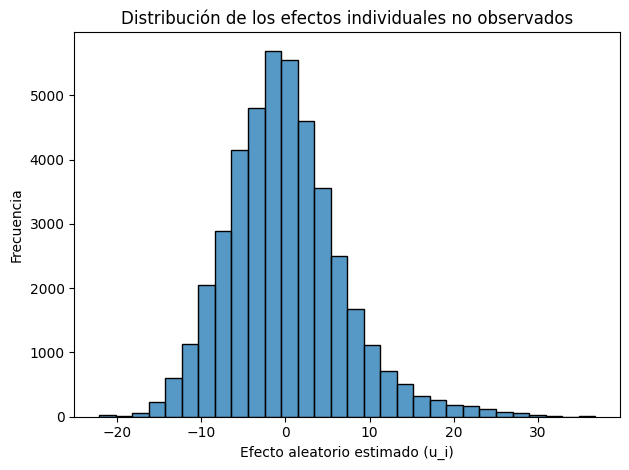

Media de u_i: -0.07204470782190737
Desviación estándar de u_i: 6.810833827988477

Resumen estadístico de u_i:
count    43058.000000
mean        -0.072045
std          6.810834
min        -22.130387
25%         -4.593536
50%         -0.553118
75%          3.707008
max         36.823551
Name: estimated_effects, dtype: float64


In [23]:
u = cre_res.estimated_effects.squeeze()

plt.figure()
sns.histplot(u, bins=30, kde=False)
plt.title('Distribución de los efectos individuales no observados')
plt.xlabel('Efecto aleatorio estimado (u_i)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()
# Media
print("Media de u_i:", u.mean())

# Desviación estándar
print("Desviación estándar de u_i:", u.std())

# Resumen estadístico completo
print("\nResumen estadístico de u_i:")
print(u.describe())

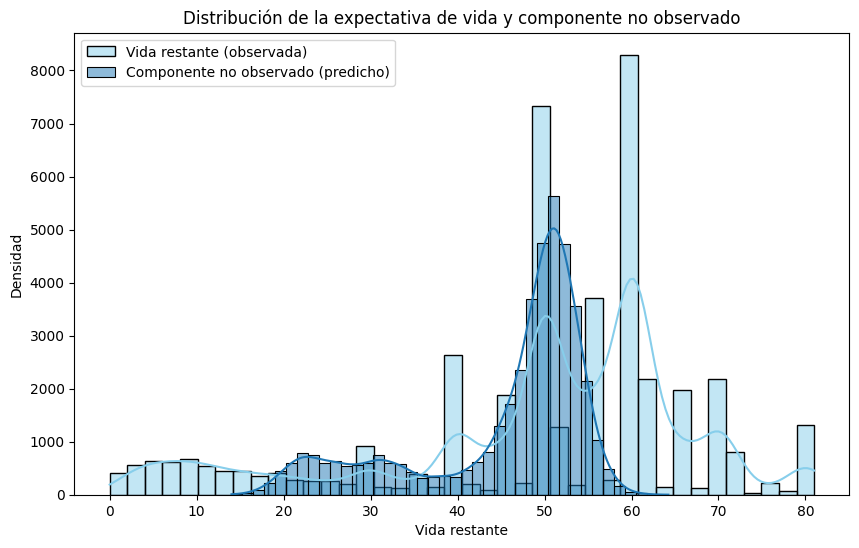

In [24]:

# Preparamos X_mean: ponemos a cero las variables "time-varying" para aislar heterogeneidad fija
X_mean = X.copy()
for col in X_cre:
    if col in X_mean.columns:
        X_mean[col] = 0

# Predicción del componente no observado (heterogeneidad fija)
y_pred_unobs = cre_res.predict(X_mean)

# Distribución observada
y_obs = y

# Graficar
plt.figure(figsize=(10,6))
sns.histplot(y_obs, color='skyblue', label='Vida restante (observada)', kde=True, bins=40)
sns.histplot(y_pred_unobs, color='red', label='Componente no observado (predicho)', kde=True, bins=40)
plt.title('Distribución de la expectativa de vida y componente no observado')
plt.legend()
plt.xlabel('Vida restante')
plt.ylabel('Densidad')
plt.show()


8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

__R:__ Prefiero el modelo de efectos aleatorios correlacionados, debido a que explica bien varias variables de nuestro estudio y nos ilustra más sobre el efecto de estas variables a medida que pasa el tiempo, el efecto que estas tienen sobre la vida restante del individuo suele ser más significativo en las variables que no cambian con el paso del tiempo, como por ejemplo la que nos indica si es que el individuo se encuentra actualmente inscrito en el sistema de pensiones o la que nos indica si es que el individuo tiene algun tipo de enfermedad crónica.

__ANEXO:__

Anexo 1: Tabla con los valores de la columna occupation.

| **Cód.** | **Nombre del código**                                                         |
| -------- | ----------------------------------------------------------------------------- |
| 1        | Directores, gerentes y administradores                                        |
| 2        | Profesionales, científicos e intelectuales                                    |
| 3        | Técnicos y profesionales de nivel medio                                       |
| 4        | Personal de apoyo administrativo                                              |
| 5        | Trabajadores de los servicios y vendedores de comercios y mercados            |
| 6        | Agricultores y trabajadores calificados agropecuarios, forestales y pesqueros |
| 7        | Artesanos y operarios de oficios                                              |
| 8        | Operadores de instalaciones, máquinas y ensambladores                         |
| 9        | Ocupaciones elementales                                                       |
| 10       | Otros no identificados                                                        |

Anexo 2: Matriz de correlación.

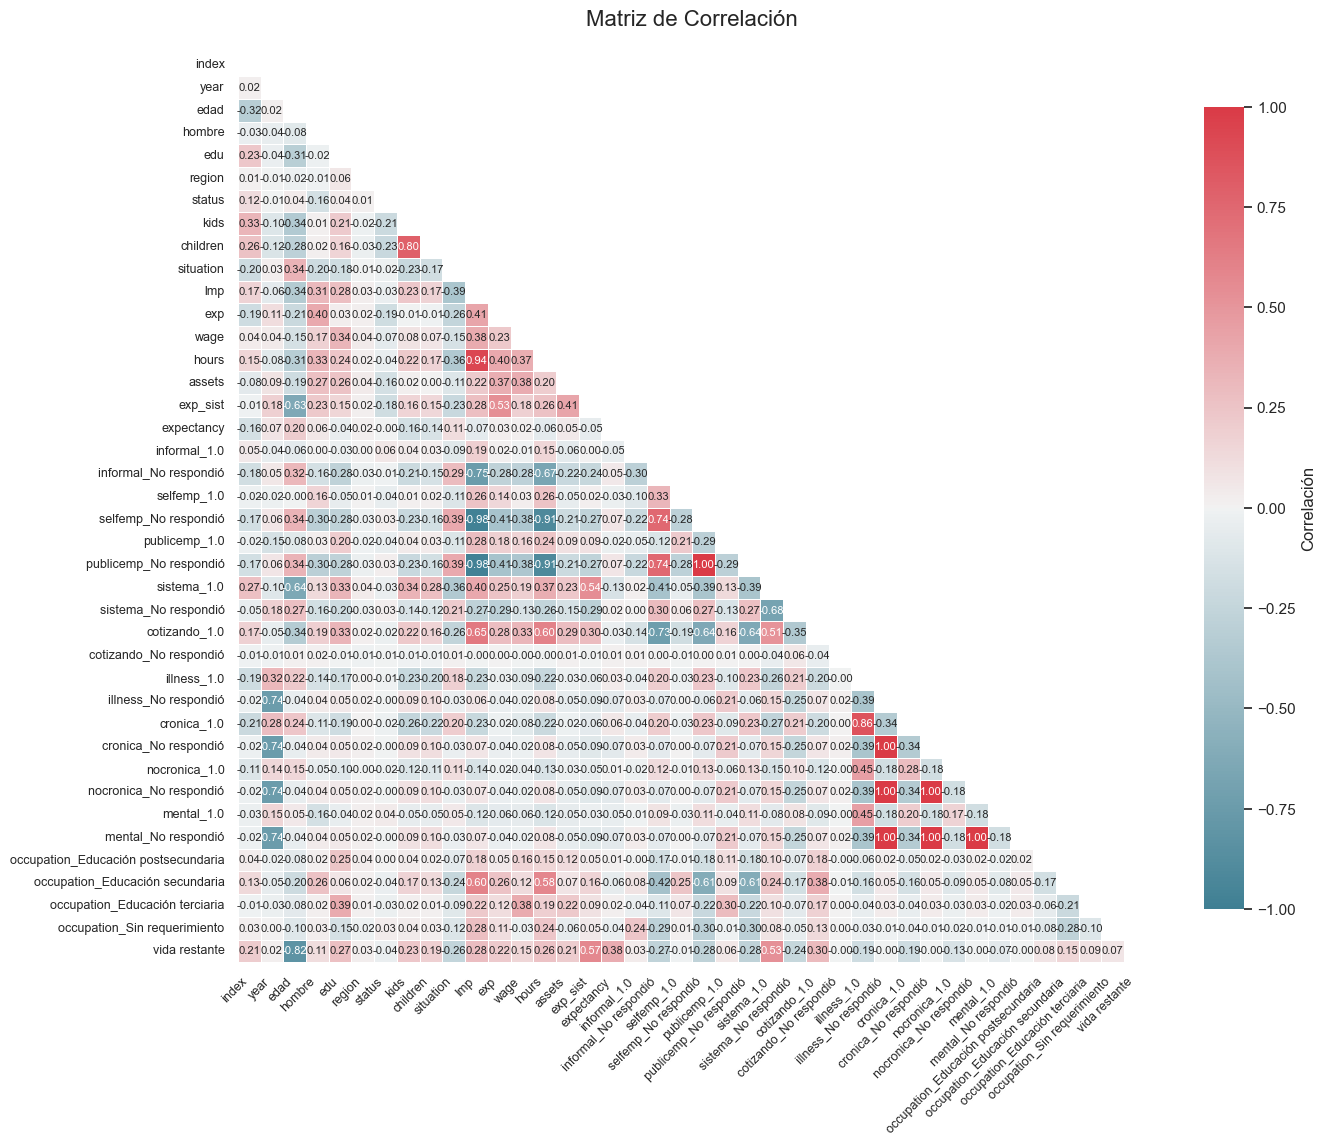

In [25]:
# Calcula la matriz de correlación
corr = dfcorr.corr()

# Máscara para la mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Estilo de seaborn
sns.set(style="white")

# Tamaño del gráfico
f, ax = plt.subplots(figsize=(14, 12))

# Paleta de colores mejorada
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Mapa de calor
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, 'label': 'Correlación'},
    annot=True,  # Muestra los valores numéricos
    fmt=".2f",   # Dos decimales
    annot_kws={"size": 8}
)

# Rota las etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

# Título
plt.title("Matriz de Correlación", fontsize=16, pad=20)

# Mostrar el gráfico
plt.tight_layout()
plt.show()